In [165]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [166]:
def f(x):
    return 3*x**2 - 4*x +5

In [167]:
f(3.0)

20.0

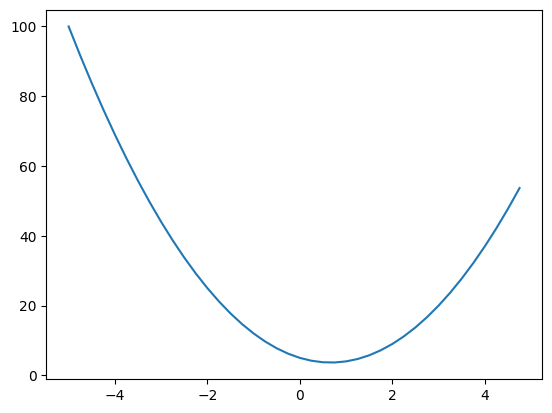

In [168]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.00000000001
x = 2/3
(f(x + h) - f(x))/h

0.0

: 

: 

In [169]:
# A little bit more complex

a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [170]:
h = 0.0001

# define the inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
a += h
d2 = a * b + c

print("d1:", d1)
print("d2:", d2)
print("slope:", (d2 - d1)/h)

d1: 4.0
d2: 3.999699999999999
slope: -3.000000000010772


In [171]:
h = 0.0001

# define the inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
b += h
d2 = a * b + c

print("d1:", d1)
print("d2:", d2)
print("slope:", (d2 - d1)/h)

d1: 4.0
d2: 4.0002
slope: 2.0000000000042206


In [172]:
h = 0.0001

# define the inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
c += h
d2 = a * b + c

print("d1:", d1)
print("d2:", d2)
print("slope:", (d2 - d1)/h)

d1: 4.0
d2: 4.0001
slope: 0.9999999999976694


In [173]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), _op="+")
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self.__add__(other)
    
    def __neg__(self):
        return self * (-1)
    
    def __sub__(self, other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op="*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), _op=f"**{other}")

        def _backward():
            self.grad = (other * self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self  * other
    
    def __truediv__(self, other):
        return self * other**-1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, _children=(self, ), _op="tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward 
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), _op="exp")

        def _backward():
            self.grad += out.data * out.grad
        
        out._backward = _backward
        return out
    
    def backward(self):
        
        topo = []

        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

        
    
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b
e.label = "e"
d = e + c
d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label = "L"
L

Value(data=-8.0)

In [174]:

from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(
        format="svg",
        graph_attr={"rankdir": "LR"}
    )

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(
            name=uid,
            label="{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape="record",
        )
        if n._op:
            dot.node(
                name=uid + n._op,
                label=n._op,
            )
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot



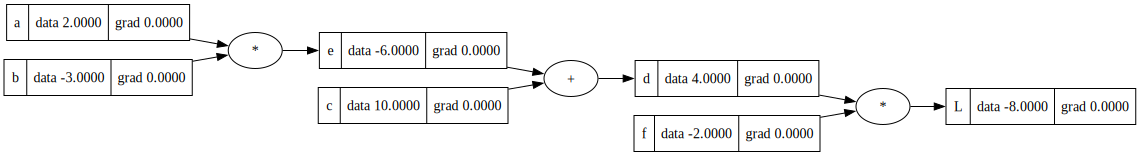

In [175]:
draw_dot(L)

In [178]:
def lol():

    h = 0.00001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b
    e.label = "e"
    e.data+=h
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L2 = L.data

    print((L2 - L1)/h)

lol()

-1.9999999999242843


In [179]:
L.grad = 1
d.grad = f.data
f.grad = d.data
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0

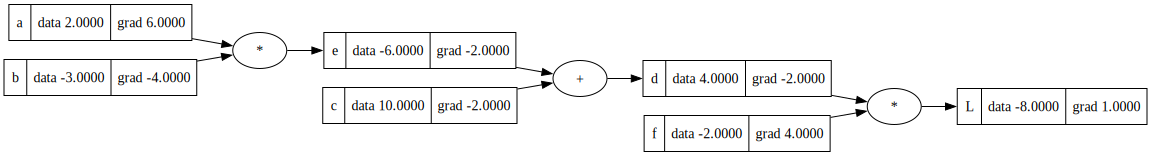

In [180]:
draw_dot(L)

In [181]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad
e = a * b
e.label = "e"
d = e + c
d.label = "d"
L = d * f; L.label = "L"
L

Value(data=-7.286496)

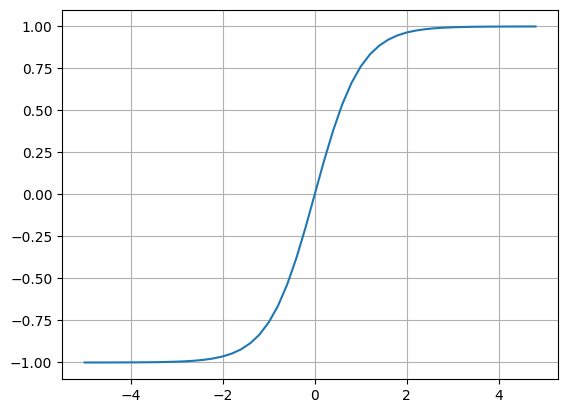

In [182]:
plt.plot(
    np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))
)

plt.grid()

## Example of a neuron manually calculating gradients

In [183]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weight w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 +b
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

o = n.tanh()
o.label = "o"


In [184]:
x1.grad = -1.5
x2.grad = 0.5
w1.grad = 1.0
w2.grad = 0.0

In [185]:
o.grad = 1.0

In [186]:
n.grad = 0.5

In [187]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [188]:
x1w1.grad = 0.5
x2w2.grad = 0.5

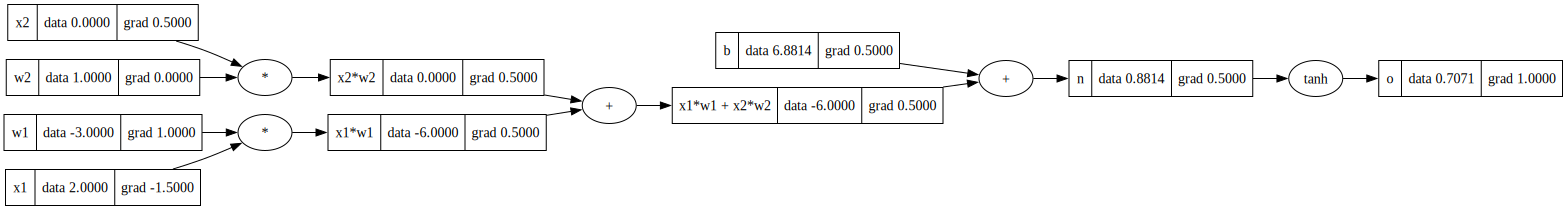

In [189]:
draw_dot(o)

## Example using the _backward function for calculating the backward

In [190]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weight w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 +b
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

o = n.tanh()
o.label = "o"

In [191]:
o.grad = 1.0

In [192]:
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

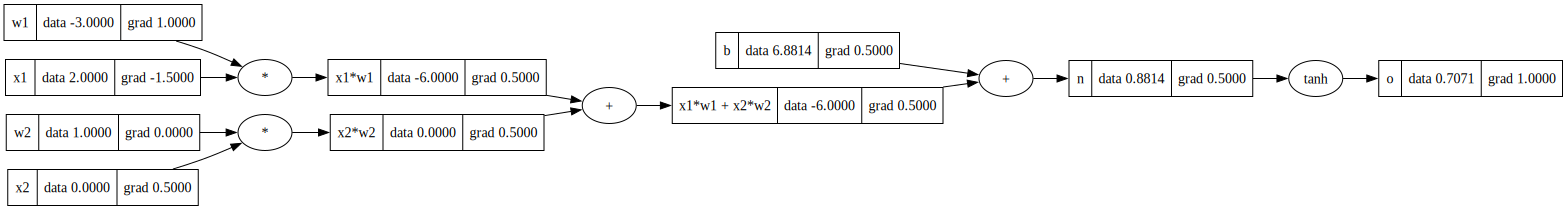

In [193]:
draw_dot(o)

## Now run it in a loop based on the reversed topological order

In [194]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weight w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 +b
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

o = n.tanh()
o.label = "o"

In [195]:
o.grad = 1.0
topo = []

visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)

In [196]:
for node in reversed(topo):
    node._backward()

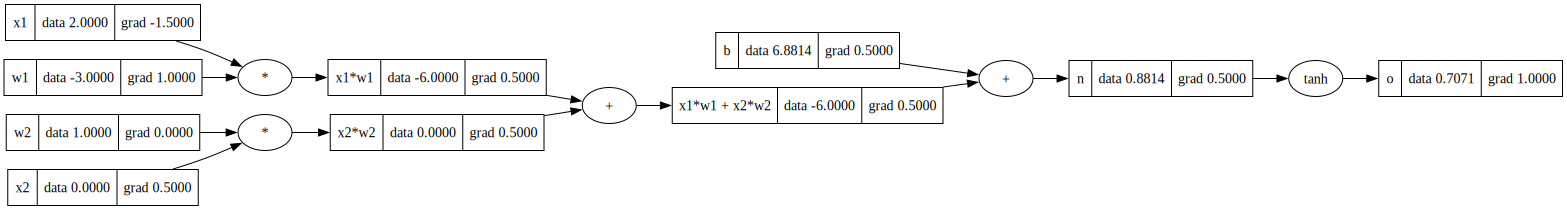

In [197]:
draw_dot(o)

## Calculate backpropagation with the Value object method

In [198]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weight w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 +b
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

o = n.tanh()
o.label = "o"

In [199]:
o.backward()

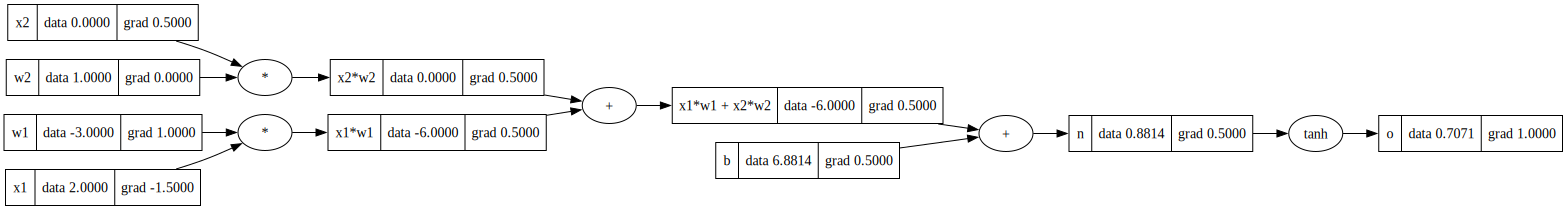

In [201]:
draw_dot(o)

## Test after adding gradients

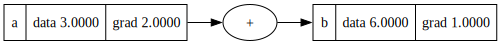

In [202]:
a = Value(3.0, label="a")
b = a + a
b.label = "b"

b.backward()

draw_dot(b)

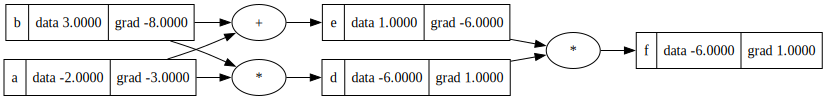

In [203]:
a = Value(-2.0, label="a")
b = Value(3.0, label="b")
d = a * b
d.label = "d"
e = a + b
e.label = "e"
f = d * e
f.label = "f"

f.backward()
draw_dot(f)

## Testing the new operations

In [204]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weight w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 +b
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

o = n.tanh()
o.label = "o"

In [205]:
o.backward()

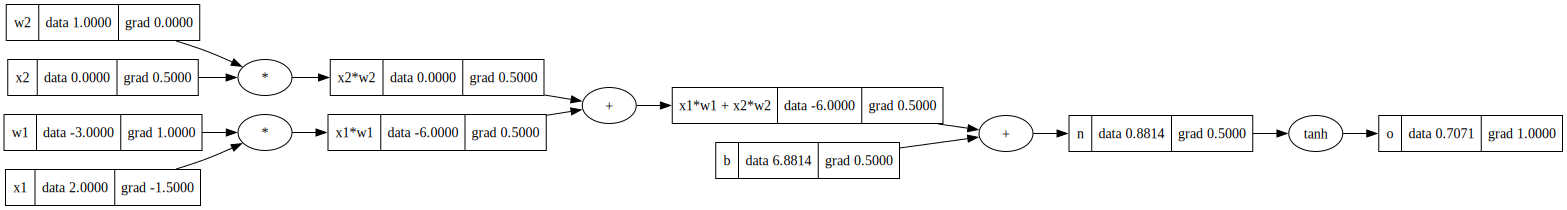

In [206]:
draw_dot(o)

In [207]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weight w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 +b
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

e = (2 * n).exp()

o = (e - 1) / (e + 1)
o.label = "o"

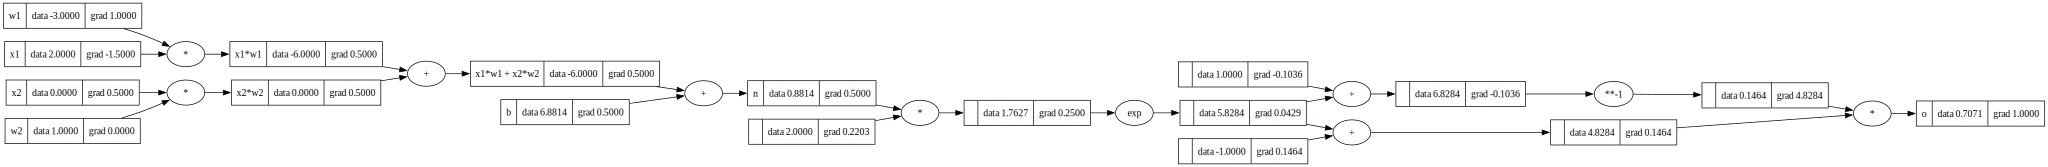

In [208]:
o.backward()
draw_dot(o)

## Now implement the exact same thing using pytorch API

In [209]:
import torch

In [211]:
x1 = torch.Tensor([2.0]).double()
x2 = torch.Tensor([0.0]).double()

w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()

b = torch.Tensor([6.8813735870195432]).double()

x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad = True

n = x1 * w1 + x2 * w2 + b

o = torch.tanh(n)

In [212]:
print(o.data.item())
o.backward()

0.7071066904050358


In [213]:
print("x1", x1.grad.item())
print("x2", x2.grad.item())
print("w1", w1.grad.item())
print("w2", w2.grad.item())

x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


## Build a two layer MLP perceptron

In [214]:
import random

In [263]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for i in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for i in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [264]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=-0.7132567317358439)

In [265]:
n = Layer(2, 3)
n(x)

[Value(data=0.9123705635094924),
 Value(data=0.818991470935819),
 Value(data=-0.9505860972353495)]

In [399]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.4207501917057787)

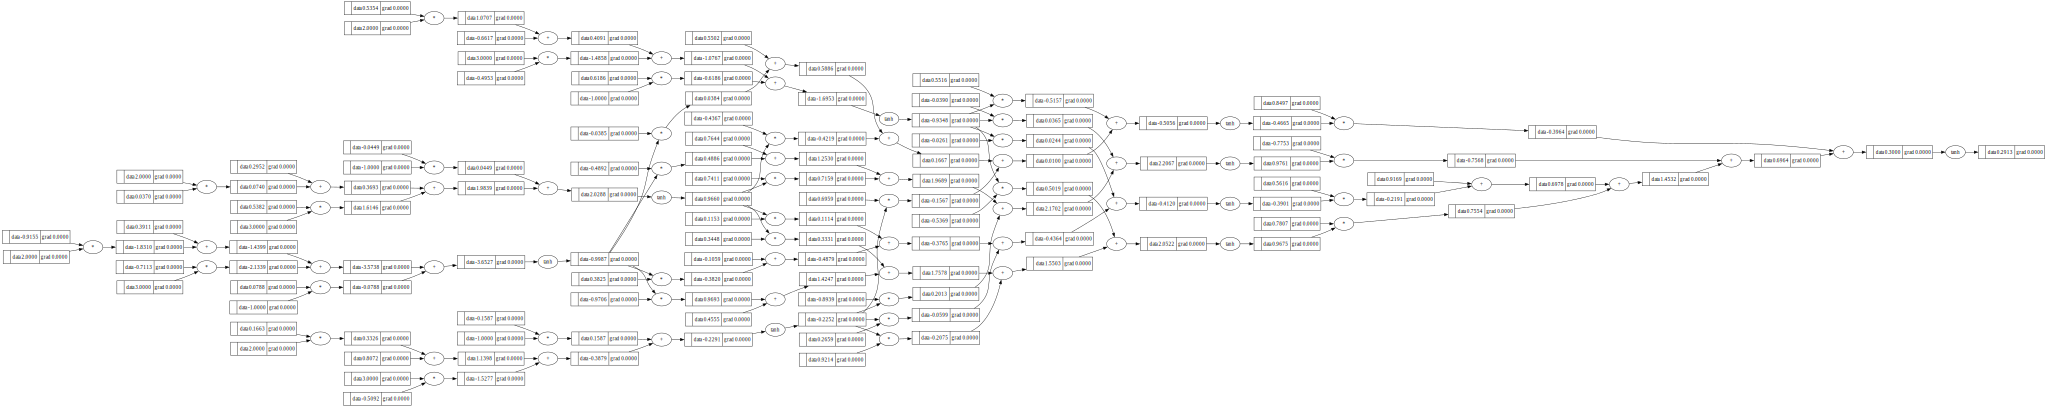

In [267]:
draw_dot(n(x))

In [400]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0] #desired targets (y1, y2, y3, y4)

In [401]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))
loss

Value(data=7.654036315787004)

In [270]:
loss.backward()

In [273]:
n.layers[0].neurons[0].w[0].grad

0.19321170916145175

In [274]:
n.layers[0].neurons[0].w[0].data

-0.9154885520712785

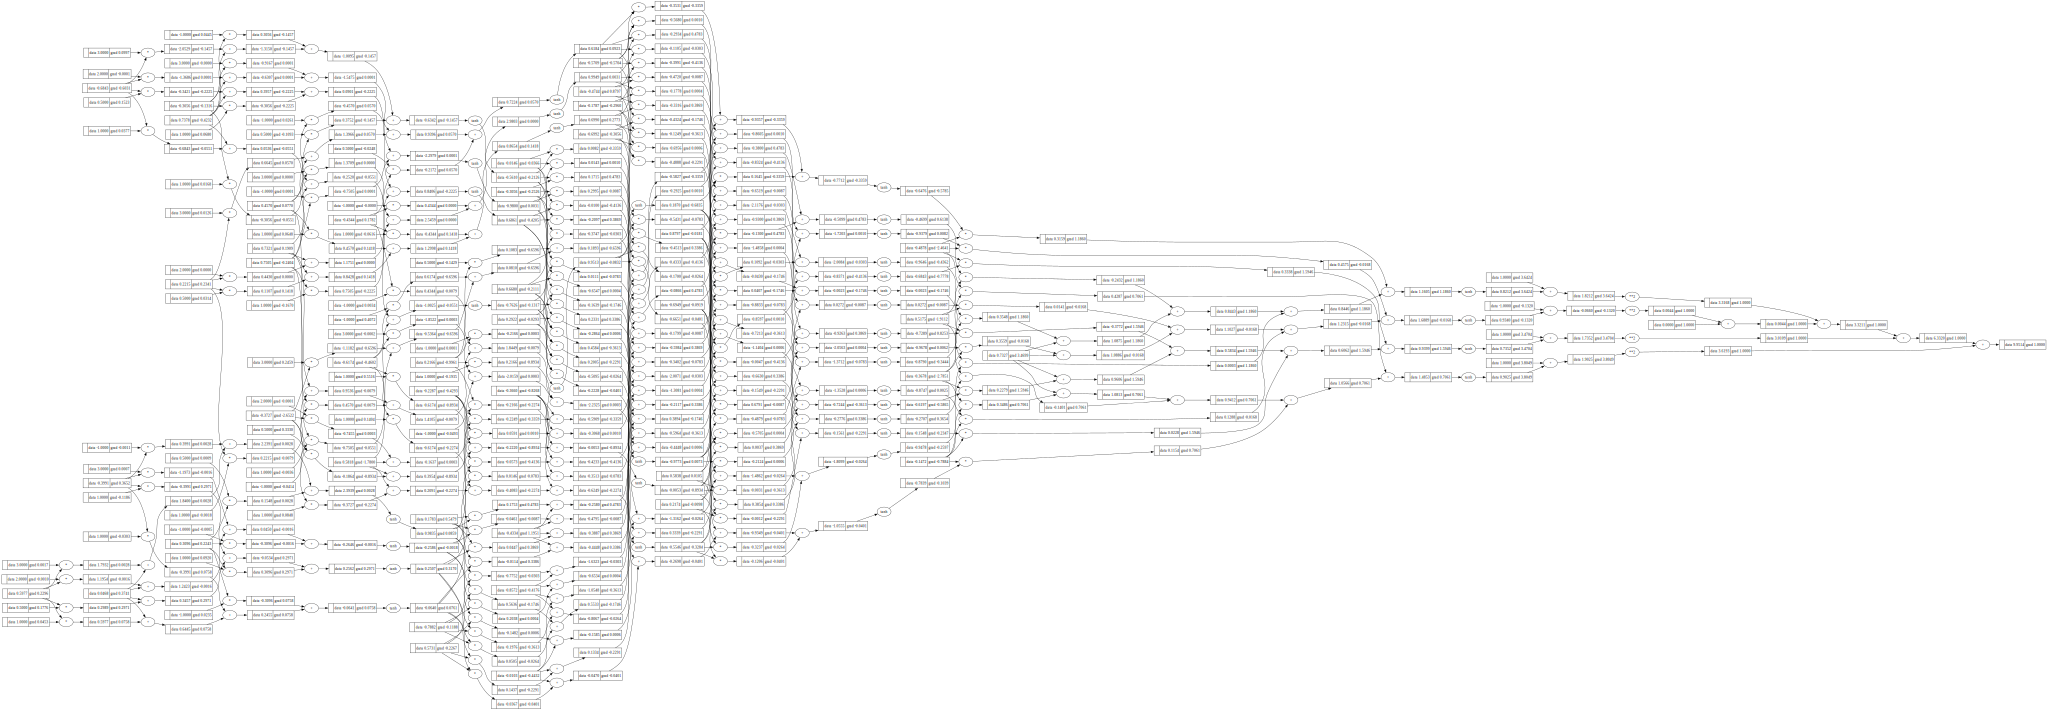

In [241]:
draw_dot(loss)

In [429]:
for p in n.parameters():
    p.data += 0.05 * (-p.grad)

In [364]:
n.layers[0].neurons[0].w[0].data

-1.5089309787665608

In [430]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))
loss

Value(data=4.0877114888505775e-05)

In [431]:
loss.backward()

In [432]:
ypred

[Value(data=0.9991570149339927),
 Value(data=-0.9983134964985977),
 Value(data=-0.9945940208363677),
 Value(data=0.9971543741832198)]

In [754]:
len(n.parameters())

41

## Now instead of doing it manually let's actually implement the training framework

In [688]:
n = MLP(3, [4, 4, 1])
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [0.9, -0.5, -0.2, 1.5] #desired targets (y1, y2, y3, y4)


In [752]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    for p in n.parameters():
        p.data += 0.01 * (-p.grad)

    print(k, loss.data)

0 0.2631294775717807
1 0.2631241748651643
2 0.2631188731516656
3 0.26311357240501565
4 0.2631082725989525
5 0.263102973707221
6 0.26309767570357323
7 0.2630923785617669
8 0.2630870822555665
9 0.2630817867587423
10 0.26307649204507033
11 0.2630711980883321
12 0.2630659048623148
13 0.26306061234081024
14 0.2630553204976154
15 0.26305002930653176
16 0.2630447387413656
17 0.26303944877592705
18 0.26303415938403046
19 0.2630288705394942


In [753]:
ypred

[Value(data=0.9790732659149256),
 Value(data=-0.49960511894188897),
 Value(data=-0.20074566918815967),
 Value(data=0.9932697194725251)]